# DroneTask — internal design inspector

This notebook reads the JavaScript source of the experiment and
reconstructs every piece of the internal design that drives what the
participant sees:

- factor labelling per block (`factors_vol`, `factors_stc`, `factors_valence`)
- latent bird / bag trajectories per design index, with change points
- the volatility-shift logic that conditionally re-assigns trajectories
- the emoji stimulus pool and the trial → emoji mapping
- the memory-task pair list and which trials each pair probes
- a simulator that, given a `randomized` permutation, tells you exactly
  which emojis appear in each *played* block and what the memory test
  will show for that block

It is purely static — it parses JS files, never runs them — so the
output is reproducible from the committed source alone.

> **Where to run from.** The notebook expects to be opened from the repo
> root (the directory that contains `index.html` and the `static/`
> folder). Adjust `REPO_ROOT` in the next cell if you keep it elsewhere.


In [1]:
from pathlib import Path
import re, json, itertools, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Where the experiment lives ===========================================
# The notebook auto-detects the repo root by walking up until it finds
# index.html. Override REPO_ROOT manually if your layout differs.
def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for ancestor in [p, *p.parents]:
        if (ancestor / "index.html").is_file() and (ancestor / "static" / "task").is_dir():
            return ancestor
    return start.resolve()

REPO_ROOT = _find_repo_root(Path.cwd())
TASK_DIR  = REPO_ROOT / "static" / "task"
INDEX_HTML = REPO_ROOT / "index.html"

print(f"Repo root : {REPO_ROOT}")
print(f"Task dir  : {TASK_DIR}")
for fname in ["stimuli.js", "stimuli-details.js", "memory_task.js",
              "trial.js", "instructions.js", "termination.js"]:
    p = TASK_DIR / fname
    print(f"  {'OK' if p.exists() else 'MISSING':<7} {fname}")
print(f"  {'OK' if INDEX_HTML.exists() else 'MISSING':<7} index.html")


Repo root : /Users/yizj/Desktop/InCogLab/DroneTask
Task dir  : /Users/yizj/Desktop/InCogLab/DroneTask/static/task
  OK      stimuli.js
  OK      stimuli-details.js
  OK      memory_task.js
  OK      trial.js
  OK      instructions.js
  OK      termination.js
  OK      index.html


In [23]:
Path("design_checks").mkdir(exist_ok=True)

## On randomization & counterbalancing across participants

- Latent bird/bag trajectories: these are mostly fixed design sequences, with a participant-level counterbalancing switch. stimuli.js defines four block factors: reward/high-vol/low-stochasticity, reward/low-vol/high-stochasticity, loss/high-vol/low-stochasticity, and loss/low-vol/high-stochasticity. It also defines base high-vol and low-vol bird/bag trajectories, then creates shifted versions by applying HIGHVOL_SHIFT_DELTA = 6 and LOWVOL_SHIFT_DELTA = -4. A participant-level random variable, reward_uses_shifted_sequences = Math.random() < 0.5, decides whether the reward blocks or loss blocks use the shifted trajectories.  ￼

- Emoji item identity: the emoji pool is a pool, not a fixed block-by-block sequence. In your notebook, you simulate assignment by shuffling the emoji pool with a seed and then assigning items sequentially across 4 blocks × 50 trials. That means the notebook is showing one simulated participant-like assignment, not a universal item order. Your actual runtime code similarly uses a shuffled emoji pool, so different participants should not necessarily see the same emoji at block 1 trial 1, block 1 trial 2, etc.

- Memory-test serial positions: these are fixed relative to each block. memory_task.js defines PREDEFINED_PAIRS as fixed 1-based within-block trial indices, for example [2,4], [6,9], [7,10], and so on. So the positions probed by the memory task are fixed across participants, but the emoji identities occupying those positions can differ because the emoji sequence is shuffled.  ￼

- Memory-test pair order: the list of pairs is fixed, but the order in which pairs are presented is randomized independently by block. nextPairForBlock() initializes pairOrderByBlock[block] as jsPsych.randomization.shuffle(PREDEFINED_PAIRS.slice()), then advances through that shuffled order. So two participants can receive the same pair positions, but in different memory-test order. 

## 1. A tiny JS-literal parser

The JS files keep design parameters as plain literals (`var name = [...];`).
We extract the right-hand side as text and convert it to Python with `json`
after stripping comments and JS-specific syntax. This is robust for the
literal styles used in `stimuli.js`, `stimuli-details.js`, and
`memory_task.js` — it does **not** evaluate JS expressions or function
calls.


In [2]:
def _strip_js_comments(src: str) -> str:
    # remove /* ... */ blocks and // line comments (not inside strings, but
    # the source files don't put // inside strings, so this is fine)
    src = re.sub(r"/\*.*?\*/", "", src, flags=re.S)
    src = re.sub(r"(^|[^:\"'])//[^\n]*", lambda m: m.group(1), src)
    return src

def _js_literal_to_python(literal: str):
    """Convert a JS literal expression (numbers, strings, arrays, true/false/null)
    to a Python value. Trailing commas and single-quoted strings are tolerated."""
    s = literal.strip().rstrip(";").strip()
    # JS true/false/null -> JSON
    s = re.sub(r"\btrue\b", "true", s)
    s = re.sub(r"\bfalse\b", "false", s)
    s = re.sub(r"\bundefined\b", "null", s)
    # remove trailing commas before ] or }
    s = re.sub(r",\s*([\]}])", r"\1", s)
    # single-quoted strings -> double-quoted (no apostrophes appear inside
    # the relevant literals in this project)
    s = re.sub(r"'((?:[^'\\]|\\.)*)'", r'"\1"', s)
    return json.loads(s)

def parse_var_assignments(js_text: str) -> dict:
    """Find every `var NAME = <literal>;` at the top level and return a dict.
    Only captures literal RHSs (numbers, strings, arrays, objects, bools).
    Function calls and expressions are skipped."""
    src = _strip_js_comments(js_text)
    out = {}
    # match: var NAME = <RHS> ;   where RHS may contain balanced [ ] { }
    pattern = re.compile(
        r"\bvar\s+([A-Za-z_$][\w$]*)\s*=\s*",
        re.M,
    )
    for m in pattern.finditer(src):
        name = m.group(1)
        i = m.end()
        # walk forward, tracking bracket depth, to find the terminating ;
        depth_sq = depth_cu = depth_pa = 0
        in_str = None
        end = None
        j = i
        while j < len(src):
            ch = src[j]
            if in_str:
                if ch == "\\":
                    j += 2
                    continue
                if ch == in_str:
                    in_str = None
            else:
                if ch in ('"', "'"):
                    in_str = ch
                elif ch == "[": depth_sq += 1
                elif ch == "]": depth_sq -= 1
                elif ch == "{": depth_cu += 1
                elif ch == "}": depth_cu -= 1
                elif ch == "(": depth_pa += 1
                elif ch == ")": depth_pa -= 1
                elif ch == ";" and depth_sq == 0 and depth_cu == 0 and depth_pa == 0:
                    end = j
                    break
            j += 1
        if end is None:
            continue
        rhs = src[i:end].strip()
        # only keep RHSs that look like literals (start with [ { " ' digit - + or true/false/null)
        if not rhs:
            continue
        first = rhs.lstrip()[:1]
        if first not in '[{"\'+-' and not first.isdigit() and not rhs.startswith(('true','false','null')):
            continue
        try:
            out[name] = _js_literal_to_python(rhs)
        except Exception:
            # could be a function call, expression, etc. — skip silently
            pass
    return out

# Sanity test
_test = 'var a = 1; var b = [1,2,3]; var c = "hi"; var d = [[1,2],[3,4],];'
print(parse_var_assignments(_test))


{'a': 1, 'b': [1, 2, 3], 'c': 'hi', 'd': [[1, 2], [3, 4]]}


## 2. Extract design parameters

Parse `stimuli.js`, `stimuli-details.js`, and `memory_task.js` into a
single namespace.


In [3]:
def read(path: Path) -> str:
    return path.read_text(encoding="utf-8")

stim_js   = read(TASK_DIR / "stimuli.js")
stim_d_js = read(TASK_DIR / "stimuli-details.js")
mem_js    = read(TASK_DIR / "memory_task.js")

design = {}
for src in (stim_js, stim_d_js, mem_js):
    design.update(parse_var_assignments(src))

# headline parameters
keys_of_interest = [
    "factors_vol", "factors_stc", "factors_valence",
    "HIGHVOL_SHIFT_DELTA", "LOWVOL_SHIFT_DELTA",
    "SLIDER_PAIRS", "BOUNDARY_MIDDLE_PAIRS", "NONBOUNDARY_MIDDLE_PAIRS",
    "PREDEFINED_PAIRS",
    "drop_obj_distribution_default", "drop_obj_duration_default",
    "stimuli_version",
]
for k in keys_of_interest:
    if k in design:
        v = design[k]
        preview = v if not isinstance(v, list) or len(v) <= 16 else f"{v[:8]} … (len={len(v)})"
        print(f"{k:35s} = {preview}")
    else:
        print(f"{k:35s}   <not parsed>")


factors_vol                         = [49, 4, 49, 4]
factors_stc                         = [16, 64, 16, 64]
factors_valence                     = ['reward', 'reward', 'loss', 'loss']
HIGHVOL_SHIFT_DELTA                 = 6
LOWVOL_SHIFT_DELTA                  = -4
SLIDER_PAIRS                        = [[2, 4], [11, 13], [16, 18], [22, 24], [34, 36], [39, 41]]
BOUNDARY_MIDDLE_PAIRS               = [[2, 4], [11, 13], [39, 41]]
NONBOUNDARY_MIDDLE_PAIRS            = [[16, 18], [22, 24], [34, 36]]
PREDEFINED_PAIRS                    = [[2, 4], [6, 9], [7, 10], [11, 13], [16, 18], [17, 20], [22, 24], [23, 26], [28, 31], [30, 33], [34, 36], [35, 38], [39, 41], [42, 45]]
drop_obj_distribution_default       = [-4.25, -3, -1.75, -0.75, -0.25, 0.25, 0.75, 1.75, 3, 4.25]
drop_obj_duration_default           = [350, 400, 500, 550, 600, 600, 600, 500, 500, 400]
stimuli_version                     = v09


In [4]:
# Pull out the trajectories and emoji pool as numpy / list
main_bird = np.array(design["main_bird_position"], dtype=float)
main_bag  = np.array(design["main_bag_position"],  dtype=float)
emojis    = list(design["EMOJI_STIMULUS_POOL"])

print(f"main_bird_position shape : {main_bird.shape}   (4 design indices × 50 trials)")
print(f"main_bag_position  shape : {main_bag.shape}")
print(f"EMOJI_STIMULUS_POOL len  : {len(emojis)}   (need ≥ 200 for 4 blocks × 50 trials)")
print(f"Unique emojis            : {len(set(emojis))}")
dups = pd.Series(emojis).value_counts()
print(f"Duplicate entries        : {(dups > 1).sum()} item(s) appear >1 time → {list(dups[dups>1].index)}")


main_bird_position shape : (4, 50)   (4 design indices × 50 trials)
main_bag_position  shape : (4, 50)
EMOJI_STIMULUS_POOL len  : 220   (need ≥ 200 for 4 blocks × 50 trials)
Unique emojis            : 216
Duplicate entries        : 4 item(s) appear >1 time → ['🧺', '\U0001f6df', '🛺', '🏹']


## 3. Per-block design summary

`factors_vol`, `factors_stc`, `factors_valence` are indexed by **playback
position** (the j-th block the participant plays), not by design index.
The mapping below shows the four design slots before any randomisation.


In [5]:
design_table = pd.DataFrame({
    "block_label (1-based, recorded as 'block')": range(1, 5),
    "factors_vol":      design["factors_vol"],
    "factors_stc":      design["factors_stc"],
    "factors_valence":  design["factors_valence"],
    "vol_level":  ["high" if v == 49 else "low" for v in design["factors_vol"]],
    "stc_level":  ["high" if s == 64 else "low" for s in design["factors_stc"]],
})
design_table


,"block_label (1-based, recorded as 'block')",factors_vol,factors_stc,factors_valence,vol_level,stc_level
0,1,49,16,reward,high,low
1,2,4,64,reward,low,high
2,3,49,16,loss,high,low
3,4,4,64,loss,low,high


## 4. Latent bird / bag trajectories

Four design indices (0–3). At runtime, two of them get a uniform shift
applied (controlled by `reward_uses_shifted_sequences`, randomised once
per participant). We reproduce both possibilities below.

**Note on volatility ordering**: in `stimuli.js`, design indices 0 and 2
share the same high-volatility base, and indices 1 and 3 share the
low-volatility base. The shift is what differentiates them at runtime.


In [28]:
def infer_change_points_from_sequence(seq, one_indexed=True):
    """
    Return trials where the latent position changes from the previous trial.

    If seq[1] != seq[0], the change begins at trial 2.
    With one_indexed=True, returned values match trial numbers 1..50.
    """
    seq = np.asarray(seq, dtype=float)
    change_idx = np.where(np.diff(seq) != 0)[0] + 1  # 0-based index of new trial
    if one_indexed:
        return (change_idx + 1).tolist()
    return change_idx.tolist()

In [29]:
def shift_seq(seq, delta, lo=10, hi=90):
    return np.clip(np.asarray(seq, dtype=float) + delta, lo, hi)

HIGHVOL_DELTA = design["HIGHVOL_SHIFT_DELTA"]
LOWVOL_DELTA  = design["LOWVOL_SHIFT_DELTA"]

def assemble_trajectories(reward_uses_shifted: bool):
    """Replicate stimuli.js lines 96–124."""
    hv_base_bird = main_bird[0].copy()
    lv_base_bird = main_bird[1].copy()
    hv_base_bag  = main_bag[0].copy()
    lv_base_bag  = main_bag[1].copy()

    hv_shift_bird = shift_seq(hv_base_bird, HIGHVOL_DELTA)
    hv_shift_bag  = shift_seq(hv_base_bag,  HIGHVOL_DELTA)
    lv_shift_bird = shift_seq(lv_base_bird, LOWVOL_DELTA)
    lv_shift_bag  = shift_seq(lv_base_bag,  LOWVOL_DELTA)

    if reward_uses_shifted:
        bird = np.vstack([hv_shift_bird, lv_shift_bird, hv_base_bird,  lv_base_bird])
        bag  = np.vstack([hv_shift_bag,  lv_shift_bag,  hv_base_bag,   lv_base_bag])
    else:
        bird = np.vstack([hv_base_bird,  lv_base_bird,  hv_shift_bird, lv_shift_bird])
        bag  = np.vstack([hv_base_bag,   lv_base_bag,   hv_shift_bag,  lv_shift_bag])
    return bird, bag

# ── Change points (taken from documentation in stimuli.js) ─────────────
HIGHVOL_CHANGE_POINTS = [3, 5, 11, 19, 25, 37, 39, 47]
LOWVOL_CHANGE_POINTS  = [3, 5, 11, 15, 19, 21, 25, 29, 31, 37, 39, 45, 47]

def is_high_vol(design_idx):
    return design["factors_vol"][design_idx] == 49

def shifted_status(idx, reward_uses_shifted):
    if reward_uses_shifted:
        return "shifted" if idx in [0, 1] else "base"
    else:
        return "base" if idx in [0, 1] else "shifted"

def shift_delta_for_idx(idx, reward_uses_shifted):
    status = shifted_status(idx, reward_uses_shifted)
    if status == "base":
        return 0
    return HIGHVOL_DELTA if is_high_vol(idx) else LOWVOL_DELTA

def plot_trajectories(reward_uses_shifted: bool):
    bird, bag = assemble_trajectories(reward_uses_shifted)
    fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
    axes = axes.ravel()

    for idx in range(4):
        ax = axes[idx]
        x = np.arange(1, bird.shape[1] + 1)

        base_idx = 0 if idx in [0, 2] else 1
        base_bird = main_bird[base_idx]
        base_bag = main_bag[base_idx]

        ax.plot(x, base_bird, lw=1.2, ls="--", alpha=0.35, color="C0", label="base bird")
        ax.plot(x, base_bag,  lw=1.0, ls="--", alpha=0.25, color="C1", label="base bag")

        ax.plot(x, bird[idx], lw=2, color="C0", label="assembled bird")
        ax.plot(x, bag[idx],  lw=1.2, alpha=0.8, color="C1", label="assembled bag")

        # change points for the actually assembled sequence
        cps = infer_change_points_from_sequence(bird[idx], one_indexed=True)
        for cp in cps:
            ax.axvline(cp-0.5, color="grey", lw=0.6, ls="--", alpha=0.5)

        v = "high" if is_high_vol(idx) else "low"
        s = "high" if design["factors_stc"][idx] == 64 else "low"
        val = design["factors_valence"][idx]

        status = shifted_status(idx, reward_uses_shifted)
        delta = shift_delta_for_idx(idx, reward_uses_shifted)

        ax.set_title(
            f"design idx {idx} → block {idx+1}: vol={v}, stc={s}, valence={val}\n"
            f"{status}, delta={delta:+}"
        )
        ax.set_xlabel("trial within block")
        ax.set_ylabel("position (%)")
        ax.legend(loc="upper right", fontsize=7)
        ax.set_ylim(0, 100)

    fig.suptitle(
        f"Latent trajectories — reward_uses_shifted_sequences = {reward_uses_shifted}",
        fontsize=12
    )
    fig.tight_layout()
    return fig



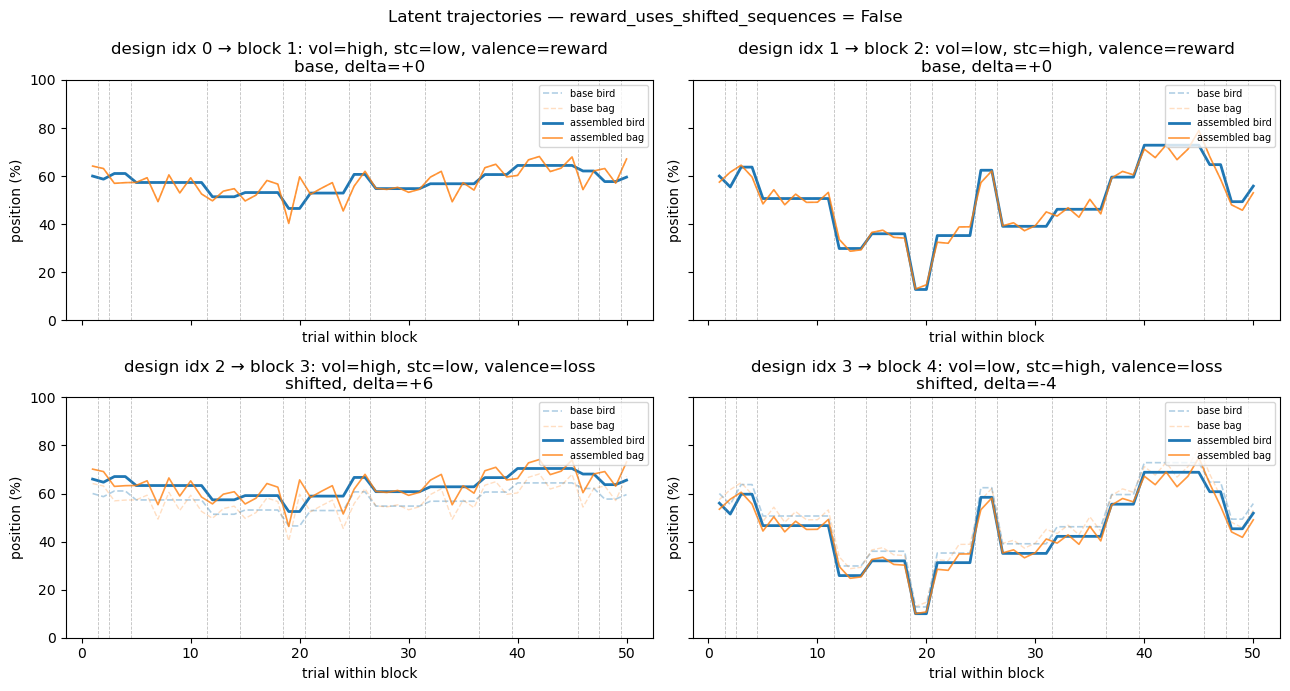

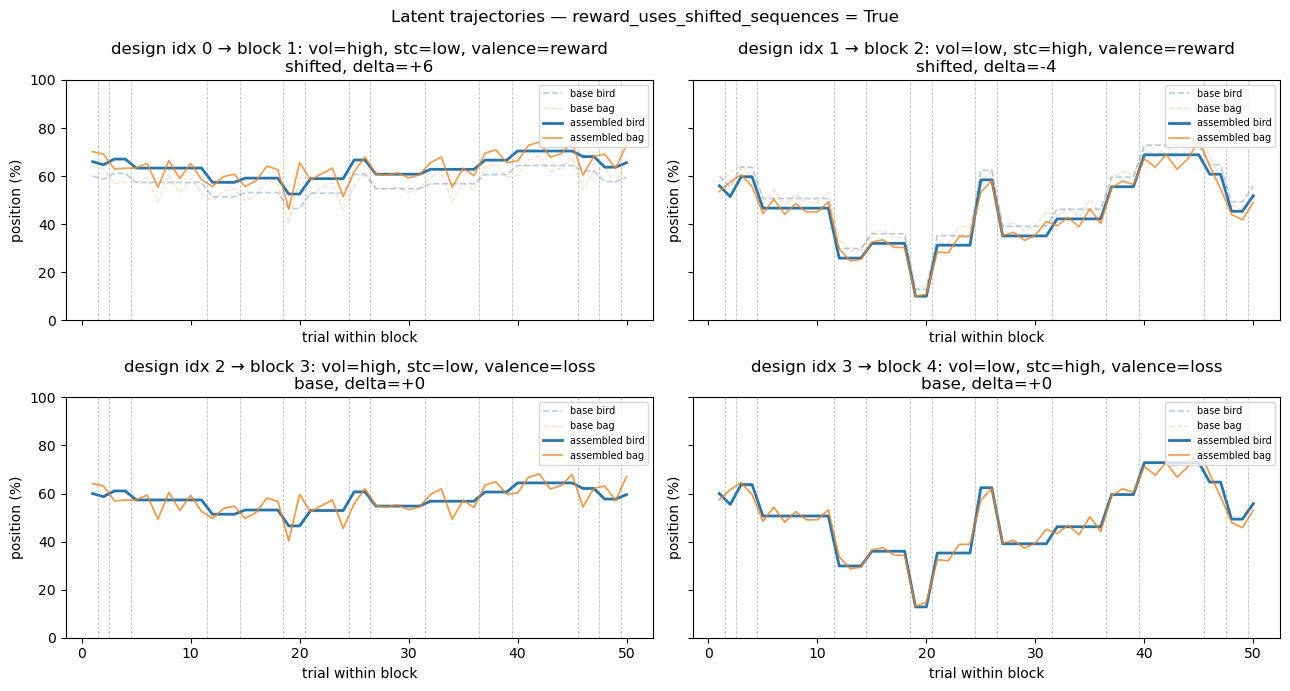

In [30]:
fig1 = plot_trajectories(reward_uses_shifted=False)
fig2 = plot_trajectories(reward_uses_shifted=True)

In [26]:
fig1.savefig(
    "design_checks/latent_trajectories_reward_uses_shifted_false.png",
    dpi=200,
    bbox_inches="tight"
)

fig2.savefig(
    "design_checks/latent_trajectories_reward_uses_shifted_true.png",
    dpi=200,
    bbox_inches="tight"
)

## 5. Memory-task pair structure

The memory test queries 14 pairs of trial indices per block. A subset of
these pairs (`SLIDER_PAIRS`) additionally asks for slider placement of
the middle item; among those, some straddle change points
(`BOUNDARY_MIDDLE_PAIRS`) and some don't (`NONBOUNDARY_MIDDLE_PAIRS`).


In [7]:
PAIRS         = design["PREDEFINED_PAIRS"]
SLIDER_PAIRS  = design["SLIDER_PAIRS"]
BOUNDARY_MID  = design["BOUNDARY_MIDDLE_PAIRS"]
NONBOUND_MID  = design["NONBOUNDARY_MIDDLE_PAIRS"]

def pair_kind(pair):
    if pair in BOUNDARY_MID:    return "slider · boundary-mid"
    if pair in NONBOUND_MID:    return "slider · non-boundary-mid"
    if pair in SLIDER_PAIRS:    return "slider"
    return "order+distance only"

pair_table = pd.DataFrame({
    "pair_id (1-based)":  range(1, len(PAIRS) + 1),
    "first_trial":  [p[0] for p in PAIRS],
    "second_trial": [p[1] for p in PAIRS],
    "middle_trial": [(p[0] + p[1]) // 2 for p in PAIRS],
    "gap":          [p[1] - p[0] for p in PAIRS],
    "kind":         [pair_kind(p) for p in PAIRS],
})
print(f"Total pairs: {len(PAIRS)}")
print(f"Trials probed (union): {sorted(set(itertools.chain.from_iterable(PAIRS)))}")
print(f"Max trial index used:  {max(itertools.chain.from_iterable(PAIRS))}  (must be ≤ trials_per_block)")
pair_table


Total pairs: 14
Trials probed (union): [2, 4, 6, 7, 9, 10, 11, 13, 16, 17, 18, 20, 22, 23, 24, 26, 28, 30, 31, 33, 34, 35, 36, 38, 39, 41, 42, 45]
Max trial index used:  45  (must be ≤ trials_per_block)


,pair_id (1-based),first_trial,second_trial,middle_trial,gap,kind
0,1,2,4,3,2,slider · boundary-mid
1,2,6,9,7,3,order+distance only
2,3,7,10,8,3,order+distance only
3,4,11,13,12,2,slider · boundary-mid
4,5,16,18,17,2,slider · non-boundary-mid
5,6,17,20,18,3,order+distance only
6,7,22,24,23,2,slider · non-boundary-mid
7,8,23,26,24,3,order+distance only
8,9,28,31,29,3,order+distance only
9,10,30,33,31,3,order+distance only


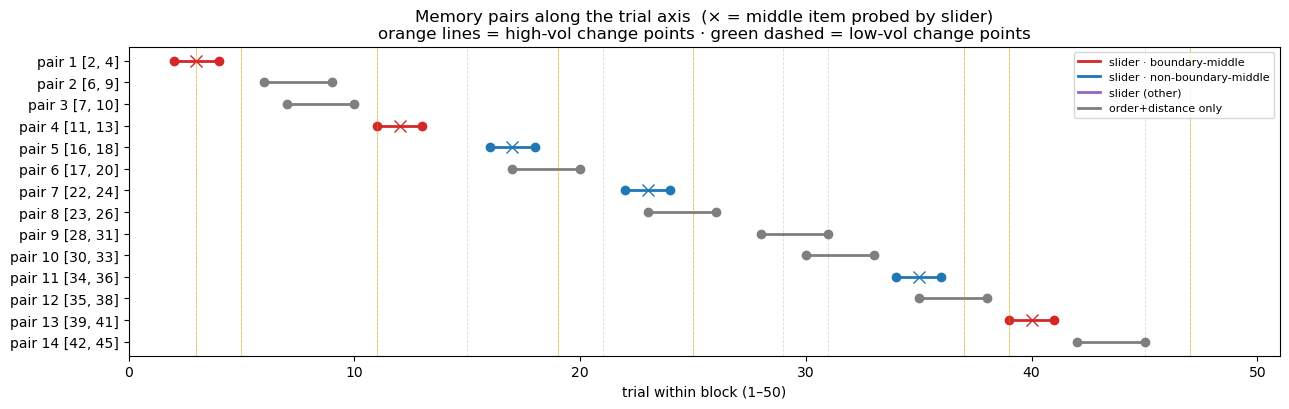

In [8]:
# Visualise pair coverage along the trial axis
fig, ax = plt.subplots(figsize=(13, 4.2))
N_TRIALS = 50
for i, p in enumerate(PAIRS):
    y = i + 1
    color = {
        "slider · boundary-mid":     "#d62728",
        "slider · non-boundary-mid": "#1f77b4",
        "slider":                    "#9467bd",
        "order+distance only":       "#7f7f7f",
    }[pair_kind(p)]
    ax.plot([p[0], p[1]], [y, y], "-", color=color, lw=2)
    ax.plot(p[0], y, "o", color=color)
    ax.plot(p[1], y, "o", color=color)
    if p in SLIDER_PAIRS:
        m = (p[0] + p[1]) // 2
        ax.plot(m, y, "x", color=color, markersize=9)

# overlay change points for both volatility levels
for cp in HIGHVOL_CHANGE_POINTS:
    ax.axvline(cp, color="orange", lw=0.8, alpha=0.35)
for cp in LOWVOL_CHANGE_POINTS:
    ax.axvline(cp, color="green",  lw=0.6, alpha=0.20, ls="--")

ax.set_yticks(range(1, len(PAIRS) + 1))
ax.set_yticklabels([f"pair {i+1} {p}" for i, p in enumerate(PAIRS)])
ax.set_xlabel("trial within block (1–50)")
ax.set_xlim(0, N_TRIALS + 1)
ax.invert_yaxis()
ax.set_title("Memory pairs along the trial axis  (× = middle item probed by slider)\n"
             "orange lines = high-vol change points · green dashed = low-vol change points")

# legend
import matplotlib.patches as mp
handles = [
    plt.Line2D([0],[0], color="#d62728", lw=2, label="slider · boundary-middle"),
    plt.Line2D([0],[0], color="#1f77b4", lw=2, label="slider · non-boundary-middle"),
    plt.Line2D([0],[0], color="#9467bd", lw=2, label="slider (other)"),
    plt.Line2D([0],[0], color="#7f7f7f", lw=2, label="order+distance only"),
]
ax.legend(handles=handles, loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()


## 6. Emoji → trial mapping

The pool is shuffled once per participant at page load, then traversed
sequentially: trial *k* (0-indexed across the whole task) gets emoji
`pool[k % len(pool)]`. Block 1 gets `k=0..49`, block 2 gets `k=50..99`,
etc. **The shuffle in `randomized` does NOT affect emoji selection** —
it only permutes which `bird_position` / `bag_position` array is played
in which slot.

Below is a deterministic preview using `numpy.random.default_rng(seed)`
so you can see the structure without running the experiment.


In [9]:
def simulate_emoji_assignment(seed: int = 0, n_trials_per_block: int = 50, n_blocks: int = 4):
    rng = np.random.default_rng(seed)
    pool = list(emojis)
    rng.shuffle(pool)
    rows = []
    k = 0
    for j in range(n_blocks):
        for i in range(n_trials_per_block):
            rows.append({
                "k (global)":  k,
                "block":       j + 1,
                "trial":       i + 1,
                "stim_img":    pool[k % len(pool)],
            })
            k += 1
    return pd.DataFrame(rows)

emoji_df = simulate_emoji_assignment(seed=42)
print("First and last 3 rows of each block:")
for j in range(1, 5):
    block_rows = emoji_df[emoji_df["block"] == j]
    display_df = pd.concat([block_rows.head(3), block_rows.tail(3)])
    print(f"\n── block {j} ──")
    print(display_df.to_string(index=False))


First and last 3 rows of each block:

── block 1 ──
 k (global)  block  trial stim_img
          0      1      1        🚦
          1      1      2        🧆
          2      1      3        🪣
         47      1     48        🧼
         48      1     49        👒
         49      1     50        🩰

── block 2 ──
 k (global)  block  trial stim_img
         50      2      1        🪻
         51      2      2        🥞
         52      2      3        🍿
         97      2     48        🫙
         98      2     49        🥩
         99      2     50        📯

── block 3 ──
 k (global)  block  trial stim_img
        100      3      1        🍶
        101      3      2        🪫
        102      3      3        📟
        147      3     48      🍋‍🟩
        148      3     49        🪘
        149      3     50       🕰️

── block 4 ──
 k (global)  block  trial stim_img
        150      4      1       ⚱️
        151      4      2        🦺
        152      4      3        📜
        197      4     48   

## 7. What the memory test will display, per block

Given the deterministic shuffle above, this shows the 14 pairs the
memory test will display for each block — i.e. exactly what
`memory_task.js` looks up via `block_trials[idx-1].stim_img`.


In [10]:
def memory_items_per_block(emoji_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for j in sorted(emoji_df["block"].unique()):
        block_df = emoji_df[emoji_df["block"] == j].set_index("trial")
        for i, p in enumerate(PAIRS, start=1):
            mid = (p[0] + p[1]) // 2
            rows.append({
                "block":    j,
                "pair_id":  i,
                "pair":     tuple(p),
                "kind":     pair_kind(p),
                "first_emoji":  block_df.loc[p[0], "stim_img"],
                "middle_emoji": block_df.loc[mid, "stim_img"] if p in SLIDER_PAIRS else "",
                "second_emoji": block_df.loc[p[1], "stim_img"],
            })
    return pd.DataFrame(rows)

mem_items = memory_items_per_block(emoji_df)
mem_items


,block,pair_id,pair,kind,first_emoji,middle_emoji,second_emoji
0,1,1,"(2, 4)",slider · boundary-mid,🧆,🪣,🧺
1,1,2,"(6, 9)",order+distance only,🤿,,📽️
2,1,3,"(7, 10)",order+distance only,🧄,,☎️
3,1,4,"(11, 13)",slider · boundary-mid,🫘,🖍️,🌺
4,1,5,"(16, 18)",slider · non-boundary-mid,🪕,🪮,👖
5,1,6,"(17, 20)",order+distance only,🪮,,🍧
6,1,7,"(22, 24)",slider · non-boundary-mid,🌻,🎹,🫖
7,1,8,"(23, 26)",order+distance only,🎹,,🍱
8,1,9,"(28, 31)",order+distance only,🎱,,🪶
9,1,10,"(30, 33)",order+distance only,🏉,,🪞


In [32]:
def infer_boundaries_from_positions(position_seq, threshold=None, quantile=0.85):
    """
    Infer large bird-position shifts from an actual latent position sequence.

    Returns:
      boundaries: list of dicts, each representing a boundary between trials.
        - after_trial: trial before the shift, 1-indexed
        - item_trial: trial immediately after the shift, 1-indexed
        - delta: signed position change
        - abs_delta: absolute position change

    Example:
      if position changes from trial 11 to trial 12,
      boundary is between 11 and 12, and item_trial is 12.
    """
    pos = np.asarray(position_seq, dtype=float)
    diffs = np.diff(pos)
    abs_diffs = np.abs(diffs)

    nonzero = abs_diffs[abs_diffs > 0]

    if threshold is None:
        if len(nonzero) == 0:
            threshold = np.inf
        else:
            threshold = np.quantile(nonzero, quantile)

    boundaries = []
    for i, d in enumerate(diffs):
        if abs(d) >= threshold and abs(d) > 0:
            boundaries.append({
                "after_trial": i + 1,      # boundary after this 1-indexed trial
                "item_trial": i + 2,       # item immediately after boundary
                "delta": float(d),
                "abs_delta": float(abs(d))
            })

    return boundaries, threshold


def build_pair_lookup(pairs):
    """
    Create trial → pair labels.

    Returns:
      pair_lookup[t] = ["P01", "P04", ...]
      pair_partner_lookup[t] = ["P01→12", ...]
    """
    pair_lookup = {}
    pair_partner_lookup = {}

    for i, pair in enumerate(pairs, start=1):
        label = f"P{i:02d}"
        a, b = pair

        pair_lookup.setdefault(a, []).append(label)
        pair_lookup.setdefault(b, []).append(label)

        pair_partner_lookup.setdefault(a, []).append(f"{label}↔{b}")
        pair_partner_lookup.setdefault(b, []).append(f"{label}↔{a}")

    return pair_lookup, pair_partner_lookup

In [37]:
# Visual: publication-style emoji ribbons with pair labels and inferred boundaries
# Output: standalone HTML suitable for screenshotting / paper figures

import numpy as np
import itertools
import html
from pathlib import Path
from IPython.display import HTML, display


def infer_boundaries_from_positions(position_seq, threshold=None, quantile=0.85):
    """
    Infer large bird-position shifts from the actual latent position sequence.

    Returns boundaries as dictionaries:
      after_trial : trial before the shift, 1-indexed
      item_trial  : trial immediately after the shift, 1-indexed
      delta       : signed bird-position change
      abs_delta   : absolute bird-position change

    Example:
      after_trial=18, item_trial=19 means the boundary occurs between
      trials 18 and 19, and trial 19 is the first post-boundary item.
    """
    pos = np.asarray(position_seq, dtype=float)
    diffs = np.diff(pos)
    abs_diffs = np.abs(diffs)

    nonzero = abs_diffs[abs_diffs > 0]

    if threshold is None:
        if len(nonzero) == 0:
            threshold = np.inf
        else:
            threshold = float(np.quantile(nonzero, quantile))

    boundaries = []
    for i, d in enumerate(diffs):
        if abs(d) >= threshold and abs(d) > 0:
            boundaries.append({
                "after_trial": i + 1,
                "item_trial": i + 2,
                "delta": float(d),
                "abs_delta": float(abs(d)),
            })

    return boundaries, threshold


def build_pair_lookup(pairs):
    """
    Create trial-level pair labels.

    Example:
      PAIRS = [(4, 7), (12, 15)]
      pair_lookup[4] = ["P01"]
      pair_lookup[7] = ["P01"]
    """
    pair_lookup = {}

    for i, pair in enumerate(pairs, start=1):
        label = f"P{i:02d}"
        a, b = pair
        pair_lookup.setdefault(a, []).append(label)
        pair_lookup.setdefault(b, []).append(label)

    return pair_lookup


def format_boundary_list(boundaries):
    """
    Format boundaries for the bottom note table.

    Example:
      18|19 ↓6.6; 20|21 ↑6.4
    """
    if not boundaries:
        return "none"

    out = []
    for b in boundaries:
        arrow = "↑" if b["delta"] > 0 else "↓"
        out.append(
            f"{b['after_trial']}|{b['item_trial']} {arrow}{abs(b['delta']):.1f}"
        )
    return "; ".join(out)


def build_emoji_ribbons_publication_html(
    emoji_df,
    bird_positions=None,
    out_path=None,
    title="DroneTask emoji ribbon design check",
    boundary_threshold=None,
    boundary_quantile=0.85,
    pairs=PAIRS,
    slider_pairs=SLIDER_PAIRS,
):
    """
    Build a static, screenshot-friendly HTML visualization.

    Visual encodings:
      yellow cell          = item used in temporal-order pair test
      blue cell            = slider middle item
      red vertical line    = boundary between previous and next item
      red outline          = first item after inferred boundary
      P01/P02/etc.         = test-pair membership, printed directly on cells
      B                    = post-boundary item marker, printed directly on cells
    """

    tested_trials = set(itertools.chain.from_iterable(pairs))
    slider_mids = set((p[0] + p[1]) // 2 for p in slider_pairs)
    pair_lookup = build_pair_lookup(pairs)

    # Compute boundary metadata by block
    boundary_items_by_block = {}
    boundary_after_by_block = {}
    boundary_notes = []

    if bird_positions is not None:
        bird_positions = np.asarray(bird_positions, dtype=float)

        for block in sorted(emoji_df["block"].unique()):
            block_idx = int(block) - 1

            boundaries, used_threshold = infer_boundaries_from_positions(
                bird_positions[block_idx],
                threshold=boundary_threshold,
                quantile=boundary_quantile,
            )

            boundary_items_by_block[block] = {b["item_trial"] for b in boundaries}
            boundary_after_by_block[block] = {b["after_trial"] for b in boundaries}

            boundary_notes.append({
                "block": int(block),
                "threshold": used_threshold,
                "boundaries": format_boundary_list(boundaries),
            })
    else:
        for block in sorted(emoji_df["block"].unique()):
            boundary_items_by_block[block] = set()
            boundary_after_by_block[block] = set()

    # Pair legend text
    pair_legend_items = []
    for i, (a, b) in enumerate(pairs, start=1):
        pair_legend_items.append(f"P{i:02d}: {a}↔{b}")
    pair_legend_text = "; ".join(pair_legend_items)

    css = """
    <style>
      body {
        font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Arial, sans-serif;
        margin: 28px;
        background: #ffffff;
        color: #222;
      }

      h1 {
        font-size: 22px;
        margin: 0 0 10px 0;
        font-weight: 750;
      }

      h2 {
        font-size: 16px;
        margin: 24px 0 8px 0;
        font-weight: 700;
      }

      .figure-note {
        font-size: 12.5px;
        color: #444;
        line-height: 1.45;
        max-width: 1350px;
        margin-bottom: 12px;
      }

      .legend {
        display: flex;
        flex-wrap: wrap;
        gap: 8px 14px;
        align-items: center;
        font-size: 12.5px;
        color: #444;
        margin: 10px 0 18px 0;
        line-height: 1.5;
      }

      .legend-item {
        display: inline-flex;
        align-items: center;
        gap: 5px;
        white-space: nowrap;
      }

      .swatch {
        display: inline-block;
        width: 18px;
        height: 14px;
        border-radius: 3px;
        vertical-align: middle;
      }

      .swatch-tested {
        background: #fff3a3;
        border: 1px solid #b58a00;
      }

      .swatch-slider {
        background: #cfe8ff;
        border: 1px solid #2b6cb0;
      }

      .swatch-boundary-item {
        background: #fff;
        border: 3px solid #d62728;
      }

      .swatch-boundary-line {
        width: 4px;
        height: 18px;
        background: #d62728;
        border-radius: 0;
      }

      .pair-legend {
        font-size: 11.5px;
        color: #444;
        line-height: 1.5;
        max-width: 1400px;
        margin: 4px 0 18px 0;
        font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace;
      }

      .emoji-ribbon-wrapper {
        margin: 10px 0 22px 0;
      }

      .emoji-ribbon-title {
        font-weight: 750;
        font-size: 14px;
        margin: 18px 0 6px 0;
      }

      table.emoji-ribbon {
        border-collapse: collapse;
        table-layout: fixed;
        width: 100%;
        max-width: 1500px;
        background: white;
        margin-bottom: 8px;
      }

      table.emoji-ribbon td {
        width: 2%;
        height: 62px;
        text-align: center;
        vertical-align: middle;
        border: 1px solid #d2d2d2;
        font-size: 20px;
        position: relative;
        background: white;
        overflow: visible;
      }

      table.emoji-ribbon td.tested {
        background: #fff3a3;
        border-color: #b58a00;
      }

      table.emoji-ribbon td.slider-mid {
        background: #cfe8ff;
        border-color: #2b6cb0;
      }

      table.emoji-ribbon td.boundary-item {
        outline: 3px solid #d62728;
        outline-offset: -3px;
      }

      table.emoji-ribbon td.boundary-after::after {
        content: "";
        position: absolute;
        top: -7px;
        right: -2px;
        height: 76px;
        border-right: 4px solid #d62728;
        z-index: 6;
      }

      .emoji-symbol {
        display: inline-block;
        font-size: 21px;
        line-height: 1;
        margin-top: 4px;
      }

      .trial-num {
        position: absolute;
        bottom: 2px;
        right: 3px;
        font-size: 8px;
        color: #777;
      }

      .pair-label {
        position: absolute;
        top: 2px;
        left: 2px;
        font-size: 8px;
        line-height: 1.05;
        color: #5b4400;
        font-weight: 800;
        background: rgba(255, 255, 255, 0.82);
        border-radius: 3px;
        padding: 1px 2px;
        font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace;
      }

      .slider-label {
        position: absolute;
        top: 2px;
        right: 2px;
        font-size: 8px;
        color: #004b88;
        font-weight: 800;
        background: rgba(255, 255, 255, 0.82);
        border-radius: 3px;
        padding: 1px 2px;
        font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace;
      }

      .boundary-label {
        position: absolute;
        bottom: 2px;
        left: 3px;
        font-size: 9px;
        color: #d62728;
        font-weight: 900;
        background: rgba(255, 255, 255, 0.88);
        border-radius: 3px;
        padding: 0 3px;
        z-index: 7;
        font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace;
      }

      .boundary-table {
        border-collapse: collapse;
        margin-top: 8px;
        font-size: 12.5px;
        background: white;
        max-width: 1200px;
      }

      .boundary-table th,
      .boundary-table td {
        border: 1px solid #d6d6d6;
        padding: 6px 8px;
        text-align: left;
        vertical-align: top;
      }

      .boundary-table th {
        background: #f1f1f1;
        font-weight: 700;
      }

      .boundary-table td:nth-child(1),
      .boundary-table td:nth-child(2) {
        white-space: nowrap;
      }

      .caption {
        font-size: 12.5px;
        color: #444;
        line-height: 1.45;
        max-width: 1350px;
        margin-top: 12px;
      }

      code {
        background: #f4f4f4;
        border: 1px solid #ddd;
        padding: 1px 4px;
        border-radius: 3px;
      }
    </style>
    """

    parts = [
        "<!DOCTYPE html>",
        "<html>",
        "<head>",
        '<meta charset="UTF-8">',
        f"<title>{html.escape(title)}</title>",
        css,
        "</head>",
        "<body>",
        f"<h1>{html.escape(title)}</h1>",
        '<div class="figure-note">'
        "Each row shows the 50-item sequence for one block. Pair-test items, slider middle items, "
        "and inferred latent-position boundaries are marked directly on the ribbon."
        "</div>",
        '<div class="legend">',
        '<span class="legend-item"><span class="swatch swatch-tested"></span>pair-tested item</span>',
        '<span class="legend-item"><span class="swatch swatch-slider"></span>slider middle item</span>',
        '<span class="legend-item"><span class="swatch swatch-boundary-item"></span>first post-boundary item</span>',
        '<span class="legend-item"><span class="swatch swatch-boundary-line"></span>boundary between items</span>',
        '<span class="legend-item"><strong>P01, P02, …</strong> test-pair ID printed on item cells</span>',
        '<span class="legend-item"><strong>B</strong> first item after large bird-position shift</span>',
        "</div>",
        f'<div class="pair-legend"><strong>Pair IDs:</strong> {html.escape(pair_legend_text)}</div>',
        '<div class="emoji-ribbon-wrapper">',
    ]

    # Ribbon tables
    for block in sorted(emoji_df["block"].unique()):
        block_df = emoji_df[emoji_df["block"] == block].sort_values("trial").set_index("trial")

        boundary_items = boundary_items_by_block.get(block, set())
        boundary_after = boundary_after_by_block.get(block, set())

        parts.append(f'<div class="emoji-ribbon-title">Block {block}</div>')
        parts.append('<table class="emoji-ribbon"><tr>')

        for t in range(1, 51):
            stim = block_df.loc[t, "stim_img"]

            classes = []
            if t in tested_trials:
                classes.append("tested")
            if t in slider_mids:
                classes.append("slider-mid")
            if t in boundary_items:
                classes.append("boundary-item")
            if t in boundary_after:
                classes.append("boundary-after")

            class_str = " ".join(classes)

            pair_labels = pair_lookup.get(t, [])
            pair_html = ""
            if pair_labels:
                pair_html = f'<div class="pair-label">{"<br>".join(pair_labels)}</div>'

            slider_html = ""
            if t in slider_mids:
                slider_html = '<div class="slider-label">MID</div>'

            boundary_html = ""
            if t in boundary_items:
                boundary_html = '<div class="boundary-label">B</div>'

            safe_stim = html.escape(str(stim))

            parts.append(
                f'<td class="{class_str}">'
                f'{pair_html}'
                f'{slider_html}'
                f'{boundary_html}'
                f'<span class="emoji-symbol">{safe_stim}</span>'
                f'<div class="trial-num">{t}</div>'
                f'</td>'
            )

        parts.append("</tr></table>")

    parts.append("</div>")

    # Boundary notes table, placed collectively below the figure
    if bird_positions is not None:
        parts.extend([
            "<h2>Boundary summary</h2>",
            '<div class="caption">'
            'Boundaries are inferred from large trial-to-trial changes in the latent bird position. '
            'For example, <code>18|19 ↓6.6</code> means the boundary occurs between trials 18 and 19; '
            'trial 19 is the first post-boundary item, and the bird moved down by 6.6 percentage points.'
            "</div>",
            '<table class="boundary-table">',
            "<tr><th>Block</th><th>Rule</th><th>Boundary locations</th></tr>",
        ])

        for note in boundary_notes:
            if np.isinf(note["threshold"]):
                rule = "no nonzero shifts"
            else:
                rule = f"jump ≥ {note['threshold']:.2f} pts"

            parts.append(
                "<tr>"
                f"<td>Block {note['block']}</td>"
                f"<td>{html.escape(rule)}</td>"
                f"<td>{html.escape(note['boundaries'])}</td>"
                "</tr>"
            )

        parts.append("</table>")

    parts.extend([
        "</body>",
        "</html>",
    ])

    html_text = "\n".join(parts)

    if out_path is not None:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        out_path.write_text(html_text, encoding="utf-8")
        print(f"Saved: {out_path}")

    return html_text


def plot_emoji_ribbons_publication_html(
    emoji_df,
    bird_positions=None,
    out_path=None,
    boundary_threshold=None,
    boundary_quantile=0.85,
):
    html_text = build_emoji_ribbons_publication_html(
        emoji_df=emoji_df,
        bird_positions=bird_positions,
        out_path=out_path,
        title="DroneTask emoji ribbon design check",
        boundary_threshold=boundary_threshold,
        boundary_quantile=boundary_quantile,
    )
    display(HTML(html_text))
    return html_text

In [38]:
assembled_bird, assembled_bag = assemble_trajectories(reward_uses_shifted=False)

html_text = plot_emoji_ribbons_publication_html(
    emoji_df,
    bird_positions=assembled_bird,
    out_path="design_checks/emoji_ribbons_publication.html",
    boundary_threshold=8
)

Saved: design_checks/emoji_ribbons_publication.html


## 8. Randomisation simulator — metadata vs. trajectory

`index.html` does `randomized = jsPsych.randomization.shuffle([0,1,2,3])`,
then plays trajectory `main_bird_position[randomized[j]]` for the j-th
block while still labelling that block with `factors_vol[j]`,
`factors_stc[j]`, `factors_valence[j]`. **This means the recorded vol/stc
factors are not always the actual vol/stc level played** (because design
indices 0,1,2,3 correspond to `[high, low, high, low]` volatility, and a
random permutation does not preserve that pattern).

This DOES NOT affect the emoji items shown in the memory test (which is
your stated symptom — see the conclusion at the bottom). It IS a
real metadata bug for any analysis that relies on recorded vol/stc
labels, and you should be aware of it.


In [12]:
def simulate_run(randomized=None, reward_uses_shifted=False):
    if randomized is None:
        randomized = list(np.random.permutation(4))
    bird, bag = assemble_trajectories(reward_uses_shifted)
    rows = []
    for j, design_idx in enumerate(randomized):
        rec_vol = design["factors_vol"][j]
        rec_stc = design["factors_stc"][j]
        rec_val = design["factors_valence"][j]
        true_vol = design["factors_vol"][design_idx]   # vol level inherent to that trajectory
        true_stc = design["factors_stc"][design_idx]
        true_val = design["factors_valence"][design_idx]
        rows.append({
            "playback_j":            j,
            "recorded_block":        j + 1,
            "design_idx_played":     design_idx,
            "recorded_vol":          rec_vol,
            "actual_vol_of_traj":    true_vol,
            "vol_match":             rec_vol == true_vol,
            "recorded_stc":          rec_stc,
            "actual_stc_of_traj":    true_stc,
            "stc_match":             rec_stc == true_stc,
            "recorded_valence":      rec_val,
            "actual_valence":        true_val,
            "valence_match":         rec_val == true_val,
            "k_range":               f"[{j*50} … {j*50+49}]",
        })
    return pd.DataFrame(rows)

# All 24 permutations — how often does recorded vol/stc/valence match the actual trajectory?
perm_results = []
for perm in itertools.permutations(range(4)):
    df = simulate_run(list(perm))
    perm_results.append({
        "randomized":    perm,
        "vol_matches":   df["vol_match"].sum(),
        "stc_matches":   df["stc_match"].sum(),
        "val_matches":   df["valence_match"].sum(),
    })
perm_df = pd.DataFrame(perm_results)
print(f"Across {len(perm_df)} possible permutations of randomized:")
print(f"  vol matches all 4 blocks: {(perm_df.vol_matches == 4).sum()} permutations")
print(f"  stc matches all 4 blocks: {(perm_df.stc_matches == 4).sum()} permutations")
print(f"  val matches all 4 blocks: {(perm_df.val_matches == 4).sum()} permutations")
print(f"  full match (all factors, all blocks): "
      f"{((perm_df.vol_matches == 4) & (perm_df.stc_matches == 4) & (perm_df.val_matches == 4)).sum()} permutations")

# Show one example
example = simulate_run([2, 0, 3, 1])
print("\nExample for randomized = [2, 0, 3, 1]:")
example


Across 24 possible permutations of randomized:
  vol matches all 4 blocks: 4 permutations
  stc matches all 4 blocks: 4 permutations
  val matches all 4 blocks: 4 permutations
  full match (all factors, all blocks): 1 permutations

Example for randomized = [2, 0, 3, 1]:


,playback_j,recorded_block,design_idx_played,recorded_vol,actual_vol_of_traj,vol_match,recorded_stc,actual_stc_of_traj,stc_match,recorded_valence,actual_valence,valence_match,k_range
0,0,1,2,49,49,True,16,16,True,reward,loss,False,[0 … 49]
1,1,2,0,4,49,False,64,16,False,reward,reward,True,[50 … 99]
2,2,3,3,49,4,False,16,64,False,loss,loss,True,[100 … 149]
3,3,4,1,4,4,True,64,64,True,loss,reward,False,[150 … 199]


## 9. Static consistency report

A quick set of pass/fail checks against the parsed design.


In [13]:
def report():
    checks = []
    def add(label, ok, detail=""):
        checks.append({"check": label, "pass": "✓" if ok else "✗", "detail": detail})

    n_trials = main_bird.shape[1]
    n_designs = main_bird.shape[0]

    add("main_bird_position has 4 design rows", n_designs == 4, f"got {n_designs}")
    add("main_bag_position has 4 design rows",  main_bag.shape[0] == 4, f"got {main_bag.shape[0]}")
    add("bird and bag have same length",        main_bird.shape == main_bag.shape, f"{main_bird.shape} vs {main_bag.shape}")
    add("trials per block == 50",               n_trials == 50, f"got {n_trials}")

    factor_lens = {len(design["factors_vol"]), len(design["factors_stc"]), len(design["factors_valence"])}
    add("factor arrays all length 4", factor_lens == {4}, f"lengths={factor_lens}")

    add("emoji pool ≥ 200",          len(emojis) >= 200, f"got {len(emojis)}")
    add("emoji pool unique",         len(set(emojis)) == len(emojis),
        f"{len(emojis)-len(set(emojis))} duplicate(s)")

    max_pair = max(itertools.chain.from_iterable(PAIRS))
    add("max pair index ≤ trials/block", max_pair <= n_trials, f"max={max_pair}, trials={n_trials}")

    slider_ok = all(p in PAIRS for p in SLIDER_PAIRS)
    add("every SLIDER_PAIR is also in PREDEFINED_PAIRS", slider_ok)
    bd_ok = all(p in SLIDER_PAIRS for p in BOUNDARY_MID)
    add("every BOUNDARY_MIDDLE_PAIR is in SLIDER_PAIRS", bd_ok)
    nb_ok = all(p in SLIDER_PAIRS for p in NONBOUND_MID)
    add("every NONBOUNDARY_MIDDLE_PAIR is in SLIDER_PAIRS", nb_ok)
    union_size = len(set(map(tuple, BOUNDARY_MID)) | set(map(tuple, NONBOUND_MID)))
    add("BOUNDARY_MID ∪ NONBOUND_MID size ≤ SLIDER_PAIRS size",
        union_size <= len(SLIDER_PAIRS), f"{union_size} vs {len(SLIDER_PAIRS)}")

    # randomization always preserves vol/stc factor labelling?
    perm_full = sum(1 for perm in itertools.permutations(range(4))
                    if all(design["factors_vol"][j] == design["factors_vol"][perm[j]] and
                           design["factors_stc"][j] == design["factors_stc"][perm[j]] and
                           design["factors_valence"][j] == design["factors_valence"][perm[j]]
                           for j in range(4)))
    add("randomized shuffle ALWAYS preserves recorded factors → trajectory match",
        perm_full == 24,
        f"only {perm_full}/24 permutations preserve all factors — see Section 8")

    return pd.DataFrame(checks)

report()


,check,pass,detail
0,main_bird_position has 4 design rows,✓,got 4
1,main_bag_position has 4 design rows,✓,got 4
2,bird and bag have same length,✓,"(4, 50) vs (4, 50)"
3,trials per block == 50,✓,got 50
4,factor arrays all length 4,✓,lengths={4}
5,emoji pool ≥ 200,✓,got 220
6,emoji pool unique,✗,4 duplicate(s)
7,max pair index ≤ trials/block,✓,"max=45, trials=50"
8,every SLIDER_PAIR is also in PREDEFINED_PAIRS,✓,
9,every BOUNDARY_MIDDLE_PAIR is in SLIDER_PAIRS,✓,


## 10. Bonus: pull the timeline structure straight from `index.html`

Just regex enough to confirm `num_birds`, `num_trials`, the `data` field
on each main trial, and the wrapper `loop_function`. Useful when you
edit `make_trials` and want to confirm the structure didn't drift.


In [14]:
html = read(INDEX_HTML)

# constants — show every assignment (the file overrides per practice branch)
def all_assignments(name):
    pattern = re.compile(rf"(?:^|\W)(?:var\s+)?{name}\s*=\s*(\d+)\s*;", re.M)
    return [int(m.group(1)) for m in pattern.finditer(html)]

print(f"num_birds  (all assignments seen): {all_assignments('num_birds')}")
print(f"num_trials (all assignments seen): {all_assignments('num_trials')}")
print(f"stayed_threshold                 : {all_assignments('stayed_threshold')}")
# Main-path canonical values are the ones inside the practice_no==0 branch:
mp = re.search(r"practice_no\s*==\s*0[^{]*\{(.*?)\n\s*\}", html, flags=re.S)
if mp:
    branch = mp.group(1)
    print(f"\nMain-path (practice_no==0) constants:")
    for name in ("num_birds", "num_trials", "missed_threshold", "warning_threshold"):
        m = re.search(rf"{name}\s*=\s*(\d+)", branch)
        if m: print(f"  {name} = {m.group(1)}")

# does the main trial definition include data: { block, trial, stim_img }?
trial_def_present = bool(re.search(
    r"data:\s*\{\s*block:\s*j\s*\+\s*1\s*,\s*randomized:.*?trial:\s*i\s*\+\s*1.*?stim_img",
    html, flags=re.S))
print(f"main trial defines data:{{block, trial, stim_img}}     : {trial_def_present}")

loop_present = bool(re.search(r"loop_function:\s*function\s*\(\s*data\s*\)\s*\{\s*return\s+data\.values\(\)\[0\]\.missing", html))
print(f"trial wrapper has loop_function on .missing            : {loop_present}")

memory_call_present = bool(re.search(r"create_memory_timeline\s*\(\s*b\s*\+\s*1\s*\)", html))
print(f"buildBirdMemoryTrials calls create_memory_timeline(b+1): {memory_call_present}")

# trial_type filter side
mem_filter_correct = bool(re.search(
    r"jsPsych\.data\.get\(\)[\s\.]*\.filter\(\{\s*trial_type:\s*['\"]trial['\"]\s*,\s*block:\s*block\s*\}\)",
    read(TASK_DIR / "memory_task.js"), flags=re.S))
print(f"memory_task.js filters by {{trial_type:'trial', block}} : {mem_filter_correct}")


num_birds  (all assignments seen): [1, 4]
num_trials (all assignments seen): [10, 1, 3, 3, 50]
stayed_threshold                 : [4]

Main-path (practice_no==0) constants:
  num_birds = 4
  num_trials = 50
  missed_threshold = 20
  warning_threshold = 16
main trial defines data:{block, trial, stim_img}     : True
trial wrapper has loop_function on .missing            : True
buildBirdMemoryTrials calls create_memory_timeline(b+1): True
memory_task.js filters by {trial_type:'trial', block} : True


## Conclusion

Putting the static analysis together:

1. **Emoji-to-trial mapping is correct.** The `k`-counter is sequential
   across blocks and is independent of `randomized`. Each block records
   `data: { block: j+1, trial: i+1, stim_img: pool[k] }` and the memory
   plugin's filter
   `jsPsych.data.get().filter({trial_type:'trial', block: block_num})`
   sorted by `trial` returns exactly the 50 emojis that were displayed
   in that block. There is no path for an emoji from another block to
   leak in.

2. **The plausible runtime explanation for "items not displayed in this
   block"** is one of:
   - running with `DEV_NTRIALS < 45` so trials at the high pair indices
     (e.g. 42, 45) don't exist → `block_trials[44]` is `undefined` and
     the displayed `stim_img` becomes blank/`undefined`;
   - the `data:` field not getting merged for some reason at runtime
     (extremely unlikely — `on_finish` already reads `dat.block` and
     `dat.trial` successfully);
   - mistaking the visual identity of one emoji for another (the pool
     is shuffled and several pairs probe nearby trials — e.g. `[6,9]`
     and `[7,10]` — which can look like "the wrong items" when scanned
     quickly).
   - The diagnostic `console.log` in section 1 of memory_task.js
     (suggested in chat) will distinguish these in seconds.

3. **The metadata-vs-trajectory mismatch in section 8 is real** but is
   independent of the memory-item question. It is worth fixing
   separately by either constraining the shuffle to permutations that
   preserve the (vol, stc, valence) tuple per block index, or by
   reading the actual played factors from `randomized[j]` when writing
   the recorded data.
